<a href="https://colab.research.google.com/github/hargagan/Machine-Learning/blob/master/Graded_assessment_DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np; import pandas as pd; from matplotlib import pyplot as plt  # Data processing and visualisation
from sklearn.datasets import  load_breast_cancer
from sklearn.model_selection import train_test_split  # Train-test split
from sklearn import tree; from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor  # Decision tree models
from sklearn.model_selection import GridSearchCV  # Cross-validation
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay  # Confusion matrix
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, accuracy_score, mean_squared_error  # Error metrics

In [ ]:
breast_cancer =  load_breast_cancer()
X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y = pd.Series(breast_cancer.target)


print(f'Input shape: {X.shape}')
print(f'Class distribution:')
for i, class_name in enumerate(breast_cancer.target_names):
    count = (y == i).sum()
    print(f'  {class_name}: {count} ({count/len(y):.1%})')

Input shape: (569, 30)
Class distribution:
  malignant: 212 (37.3%)
  benign: 357 (62.7%)


In [ ]:
train_test_split?

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, random_state = 9001, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((398, 30), (171, 30), (398,), (171,))

By setting `stratify=y`, we ensure that the train and test sets have roughly the same proportion of classes as the original dataset `y`.

In [ ]:
dt = DecisionTreeClassifier(max_depth=3, random_state=9001)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=9001)

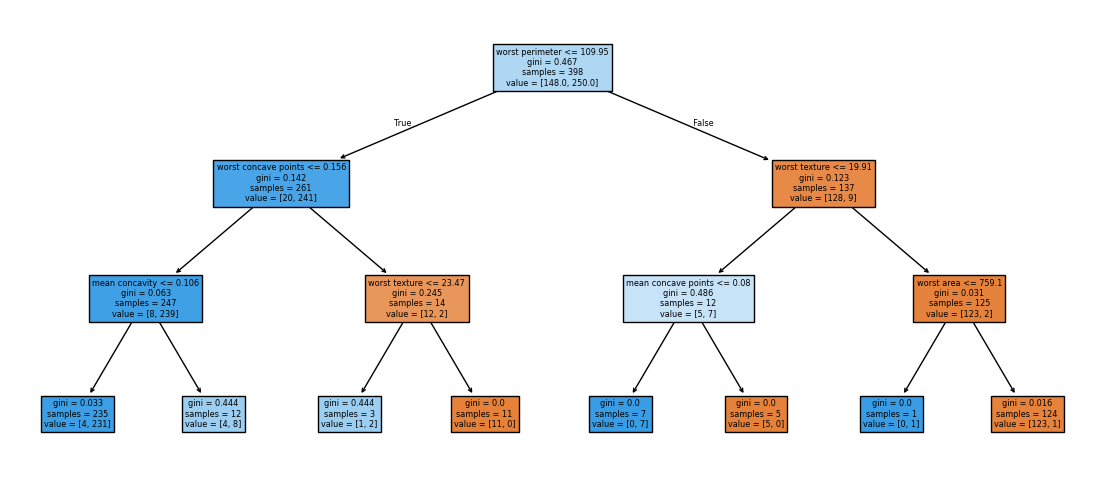

In [ ]:
fig = plt.figure(figsize = (14, 6))
fig = tree.plot_tree(dt, feature_names = X.columns, filled = True)

In [ ]:
# Perform prediction on the training and testing datasets
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

Confusion matrix for training data:
[[139   9]
 [  1 249]]


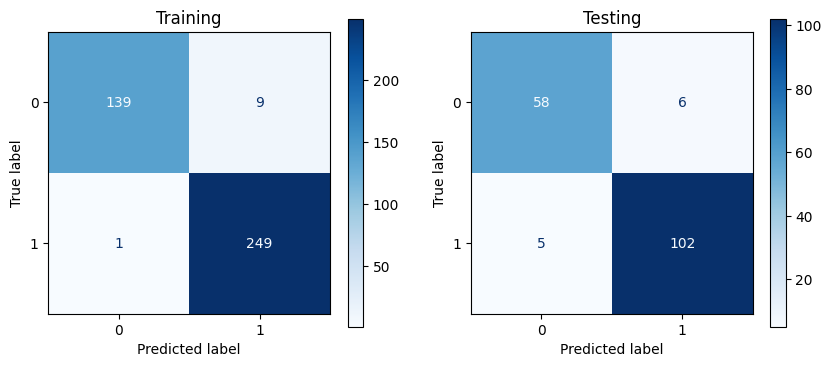

In [ ]:
# Print the confusion matrices for the training and testing data
print('Confusion matrix for training data:')
print(confusion_matrix(y_train, y_train_pred))
fig, ax = plt.subplots(1, 2, figsize = (10, 4))
ConfusionMatrixDisplay.from_estimator(dt, X_train, y_train, cmap = plt.cm.Blues, ax = ax[0])
ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test, cmap = plt.cm.Blues, ax = ax[1])
ax[0].set_title('Training')
ax[1].set_title('Testing');

In [ ]:
# Print the accuracy scores
print(f'Accuracy score on the training dataset: {round(accuracy_score(y_train_pred, y_train), 3)}')
print(f'Accuracy score on the testing dataset: {round(accuracy_score(y_test_pred, y_test), 3)}')

Accuracy score on the training dataset: 0.975
Accuracy score on the testing dataset: 0.936


In [ ]:
print(classification_report(y_test, y_test_pred, target_names = df.target_names))

              precision    recall  f1-score   support

   malignant       0.92      0.91      0.91        64
      benign       0.94      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



In [ ]:
# Create a DecisionTreeClassifier object
tree_clf = DecisionTreeClassifier(random_state = 0)

# Define the range of the max_depth parameter
param_grid = {'max_depth': np.arange(1, 11)} # Parameter range

# Perform grid search
grid = GridSearchCV(tree_clf, param_grid, cv = 5, scoring = 'accuracy', return_train_score = False, verbose = 1)
grid_search = grid.fit(X_train, y_train)

# Print the optimal value of max_depth
print('The optimal value of max_depth is', grid_search.best_params_['max_depth'])

Fitting 5 folds for each of 10 candidates, totalling 50 fits
The optimal value of max_depth is 3


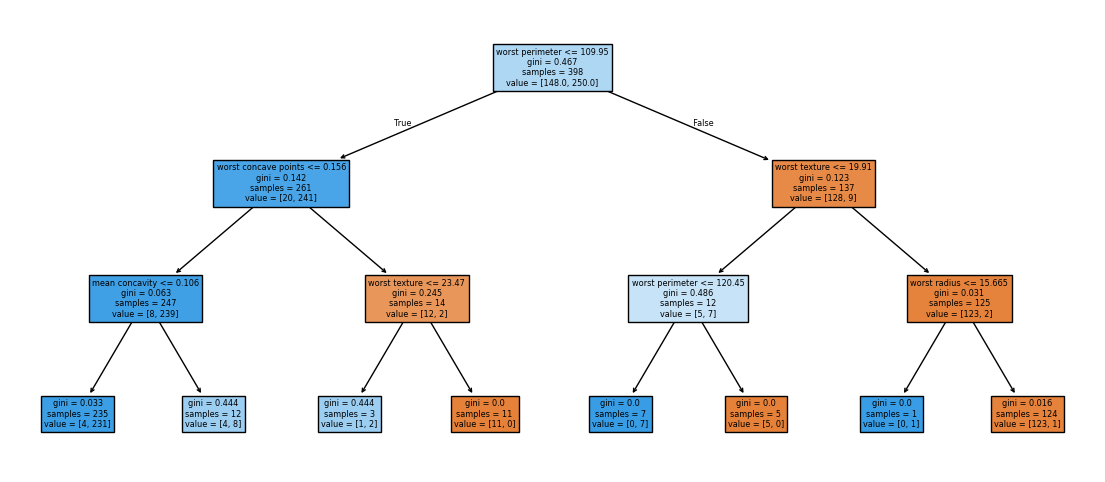

In [ ]:
# Train a tree using the optimal max_depth
best_tree_clf = DecisionTreeClassifier(random_state = 0, max_depth = grid_search.best_params_['max_depth'])
best_tree_clf = best_tree_clf.fit(X_train, y_train)

# Visualise the decision tree
fig = plt.figure(figsize = (14, 6))
fig = tree.plot_tree(best_tree_clf, feature_names = X.columns, filled = True)

In [ ]:
# Print the number of leaves and the depth of the tree
print('Number of leaves =', best_tree_clf.get_n_leaves())
print('Tree depth =', best_tree_clf.get_depth())

Number of leaves = 8
Tree depth = 3


In [ ]:
# Perform prediction on the training and testing datasets
y_train_pred = best_tree_clf.predict(X_train)
y_test_pred = best_tree_clf.predict(X_test)

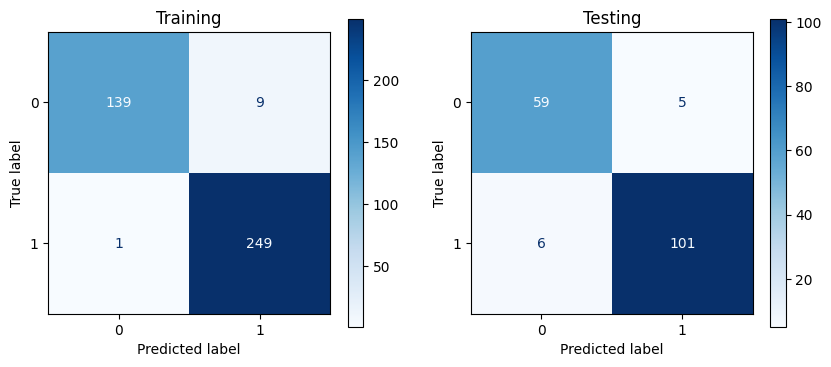

In [ ]:
# Print the confusion matrices for the training and testing data
fig, ax = plt.subplots(1, 2, figsize = (10, 4))
ConfusionMatrixDisplay.from_estimator(best_tree_clf, X_train, y_train, cmap = plt.cm.Blues, ax = ax[0])
ConfusionMatrixDisplay.from_estimator(best_tree_clf, X_test, y_test, cmap = plt.cm.Blues, ax = ax[1])
ax[0].set_title('Training')
ax[1].set_title('Testing');

In [ ]:
# Print the accuracy scores
print(f'Accuracy score on the training dataset: {round(accuracy_score(y_train_pred, y_train), 3)}')
print(f'Accuracy score on the testing dataset: {round(accuracy_score(y_test_pred, y_test), 3)}')

Accuracy score on the training dataset: 0.975
Accuracy score on the testing dataset: 0.936
